# Region-level Analyzer

Presi i risultati della nostra analisi,  si cercano pattern e comportamenti interessanti nei risultati.

Le tabelle con i risultati ottenuti da queste analisi sono salvate come csv in "regions_results"

In [ ]:
import pandas as pd
import numpy as np
import json

In [2]:
predicted_df = pd.read_csv('regions_labels_predicted.csv')
trait_json = open('Lythrum_traits_standardized.json')
traits = json.load(trait_json)

In [3]:
predicted_df.head()

,image_path,cluster_id,leaf,flower,stem,hand,background/undefined,filename,obs_id,group,y_true,y_pred
0,lythrum_virgatum_1111.jpeg_region_2.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_virgatum_1111.jpeg,33281,lythrum_virgatum,0,0
1,lythrum_salicaria_7620.jpg_region_1.png,19,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_7620.jpg,7619,lythrum_salicaria,0,0
2,lythrum_alatum_5059.jpeg_region_2.png,27,NaN,NaN,NaN,NaN,1.0,lythrum_alatum_5059.jpeg,39768,lythrum_alatum,1,1
3,lythrum_salicaria_4752.jpeg_region_2.png,12,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_4752.jpeg,4751,lythrum_salicaria,0,1
4,lythrum_alatum_2102.jpeg_region_9.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_alatum_2102.jpeg,36811,lythrum_alatum,1,1


In [3]:
label_columns = ['leaf', 'flower', 'stem', 'hand', 'background/undefined']
info_columns = ['filename', 'obs_id', 'group', 'y_true', 'y_pred']
predicted_df['group'] = predicted_df['group'].str.replace('_', ' ')

def get_characteristic_traits(row, traits_dict):
    species = row['group']  # species
    traits_for_species = traits_dict.get(species, {})
    collected_traits = []
    for label in ['leaf', 'flower', 'stem']:  # only biological traits
        if row[label] == 1:
            label_key = label if label in traits_for_species  else None
            if label_key:
                collected_traits.extend(traits_for_species[label_key])
    return collected_traits

merged_df = predicted_df[info_columns + ['hand', 'background/undefined']].copy()
merged_df['characteristic_traits'] = predicted_df.apply(lambda row: get_characteristic_traits(row, traits), axis=1)
print(merged_df.head())

                      filename  obs_id              group  y_true  y_pred  \
0   lythrum_virgatum_1111.jpeg   33281   lythrum virgatum       0       0   
1   lythrum_salicaria_7620.jpg    7619  lythrum salicaria       0       0   
2     lythrum_alatum_5059.jpeg   39768     lythrum alatum       1       1   
3  lythrum_salicaria_4752.jpeg    4751  lythrum salicaria       0       1   
4     lythrum_alatum_2102.jpeg   36811     lythrum alatum       1       1   

   hand  background/undefined  \
0   NaN                   NaN   
1   NaN                   NaN   
2   NaN                   1.0   
3   NaN                   NaN   
4   NaN                   NaN   

                               characteristic_traits  
0  [leaves opposite, sessile, getting narrower at...  
1  [leaves opposite, sessile, alternate distally,...  
2                                                 []  
3  [leaves opposite, sessile, alternate distally,...  
4  [leaves opposite, becoming alternate distally,...  


In [5]:
merged_df.columns

Index(['filename', 'obs_id', 'group', 'y_true', 'y_pred', 'hand',
       'background/undefined', 'characteristic_traits'],
      dtype='object')

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class ImprovedPlantModelAnalyzer:
    def __init__(self, df):
        """
        Initialize analyzer with plant invasiveness dataframe
        Expected columns: 'filename', 'obs_id', 'group', 'y_true', 'y_pred', 
                         'hand', 'background/undefined', 'characteristic_traits'
        """
        self.df = df.copy()
        self.prepare_data()
        
    def prepare_data(self):
        """Prepare data for analysis"""
        print("Preparing data...")

        print()
        print("In our analysis:")
        print("- True Positive = Invasive plants correctly predicted")
        print("- True Negative = Non Invasive plants correctly predicted")
        print("- False Positive = Non Invasive plants predicted as Invasive")
        print("- False Negative = Invasive plants predicted as Non Invasive")
        print()
        
        # Create model correctness indicator
        self.df['correct_prediction'] = (self.df['y_true'] == self.df['y_pred']).astype(int)
        
        # Create error type column
        self.df['error_type'] = 'Correct'
        self.df.loc[(self.df['y_true'] == 0) & (self.df['y_pred'] == 1), 'error_type'] = 'False Negative'
        self.df.loc[(self.df['y_true'] == 1) & (self.df['y_pred'] == 0), 'error_type'] = 'False Positive'
        
        # Process characteristic traits if they're in list format
        if isinstance(self.df['characteristic_traits'].iloc[0], str):
            # If stored as string representation of list, convert
            self.df['characteristic_traits'] = self.df['characteristic_traits'].apply(
                lambda x: eval(x) if x.startswith('[') else [x] if pd.notna(x) else []
            )
        
        # Create binary columns for each unique trait
        all_traits = set()
        for traits in self.df['characteristic_traits'].dropna():
            if isinstance(traits, list):
                all_traits.update(traits)
            else:
                all_traits.add(traits)
        
        self.all_traits = sorted(list(all_traits))
        
        # Create binary trait columns
        for trait in self.all_traits:
            self.df[f'has_{trait}'] = self.df['characteristic_traits'].apply(
                lambda x: 1 if isinstance(x, list) and trait in x else 0
            )
        
        print(f"Dataset prepared: {len(self.df)} samples, {len(self.all_traits)} unique traits")
    
    def bootstrap_ci(self, data1, data2, n_bootstrap=1000, ci=95):
        """Bootstrap confidence interval for difference in means."""
        diffs = []
        n1, n2 = len(data1), len(data2)
        for _ in range(n_bootstrap):
            sample1 = np.random.choice(data1, size=n1, replace=True)
            sample2 = np.random.choice(data2, size=n2, replace=True)
            diffs.append(sample1.mean() - sample2.mean())
        lower = np.percentile(diffs, (100 - ci) / 2)
        upper = np.percentile(diffs, 100 - (100 - ci) / 2)
        return (lower, upper)

    # -------------------------
    # 1. Trait Impact Analysis
    # -------------------------
    def summarize_trait_impact(self, top_n=10):
        """
        Shows which traits help or hurt model accuracy the most.
        """
        impacts = []
        for trait in self.all_traits:
            col = f'has_{trait}'
            with_trait = self.df[self.df[col] == 1]
            without_trait = self.df[self.df[col] == 0]


            if len(with_trait) >= 5:
                acc_with = with_trait['correct_prediction'].mean()
                acc_without = without_trait['correct_prediction'].mean()
                diff = acc_with - acc_without


                ci_low, ci_high = self.bootstrap_ci(with_trait['correct_prediction'].values,without_trait['correct_prediction'].values, n_bootstrap=50)


                impacts.append({
                    'trait': trait,
                    'accuracy_with': acc_with,
                    'accuracy_without': acc_without,
                    'impact': diff,
                    'ci_low': ci_low,
                    'ci_high': ci_high,
                    'n_with': len(with_trait),
                    'n_without': len(without_trait)
                    })


        impact_df = pd.DataFrame(impacts).sort_values('impact', key=abs, ascending=False)


        print(f"TOP {top_n} TRAITS BY IMPACT ON ACCURACY:")
        print("-" * 70)
        for _, row in impact_df.head(top_n).iterrows():
            direction = "HELPS" if row['impact'] > 0 else "HURTS"
            print(f"Trait: {row['trait']}")
            print(f" → Impact: {direction} by {row['impact']:+.3f} (95% CI: [{row['ci_low']:.3f}, {row['ci_high']:.3f}])")
            print(f" → Sample Sizes: With={row['n_with']} | Without={row['n_without']}")
            print()


        return impact_df

    # -------------------------
    # 2. Bias Audit Analysis
    # -------------------------
    def audit_bias(self, top_n=10):
        """
        Focuses on fairness: demographic parity, TPR/FPR, precision, recall.
        """
        audits = []
        for trait in self.all_traits:
            col = f'has_{trait}'
            with_trait = self.df[self.df[col] == 1]
            without_trait = self.df[self.df[col] == 0]


            if len(with_trait) >= 5:
                pred_rate_with = with_trait['y_pred'].mean()
                pred_rate_without = without_trait['y_pred'].mean()
                demo_parity = pred_rate_with - pred_rate_without


                def safe_rate(df, cond, col):
                    subset = df[df['y_true'] == cond]
                    return subset[col].mean() if len(subset) > 0 else np.nan


                tpr_with = safe_rate(with_trait, 0, 'y_pred')
                tpr_without = safe_rate(without_trait, 0, 'y_pred')
                fpr_with = safe_rate(with_trait, 1, 'y_pred')
                fpr_without = safe_rate(without_trait, 1, 'y_pred')


                precision_with = np.nan
                precision_without = np.nan
                recall_with = np.nan
                recall_without = np.nan
                f1_with = np.nan
                f1_without = np.nan


                for grp, df_sub in [("with", with_trait), ("without", without_trait)]:
                    tp = ((df_sub['y_true'] == 0) & (df_sub['y_pred'] == 0)).sum()
                    fp = ((df_sub['y_true'] == 1) & (df_sub['y_pred'] == 0)).sum()
                    fn = ((df_sub['y_true'] == 0) & (df_sub['y_pred'] == 1)).sum()


                    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
                    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
                    f1 = 2 * precision * recall / (precision + recall) if precision > 0 and recall > 0 else np.nan


                    if grp == "with":
                        precision_with, recall_with, f1_with = precision, recall, f1
                    else:
                        precision_without, recall_without, f1_without = precision, recall, f1


                audits.append({
                    'trait': trait,
                    'demographic_parity_diff': demo_parity,
                    'tpr_diff': tpr_with - tpr_without if not (np.isnan(tpr_with) or np.isnan(tpr_without)) else np.nan,
                    'fpr_diff': fpr_with - fpr_without if not (np.isnan(fpr_with) or np.isnan(fpr_without)) else np.nan,
                    'precision_with': precision_with,
                    'precision_without': precision_without,
                    'recall_with': recall_with,
                    'recall_without': recall_without,
                    'f1_with': f1_with,
                    'f1_without': f1_without,
                    'n_with': len(with_trait)
                    })


        audit_df = pd.DataFrame(audits)


        print(f"TOP {top_n} TRAITS WITH FAIRNESS GAPS:")
        print("-" * 70)
        for _, row in audit_df.head(top_n).iterrows():
            print(f"Trait: {row['trait']}")
            print(f" → Demographic Parity Diff: {row['demographic_parity_diff']:+.3f}")
            print(f"Stats referring to Invasive detection..")
            print(f" → TPR Diff: {row['tpr_diff']}")
            print(f" → FPR Diff: {row['fpr_diff']}")
            print(f" → Precision (With={row['precision_with']:.3f}, Without={row['precision_without']:.3f})")
            print(f" → Recall (With={row['recall_with']}, Without={row['recall_without']})")
            print(f" → F1 (With={row['f1_with']}, Without={row['f1_without']})")
            print()


        return audit_df
    
    # -------------------------
    # 3. Combined Dashboard
    # -------------------------
    def combined_trait_bias_dashboard(self, impact_df, audit_df, bias_threshold=0.1, top_n=20):
        """
        Links trait impact and bias analysis.
        Text + Visual: show traits that are risky in terms of both.
        """
        new_audit_df = audit_df.copy()
        if 'n_with' not in new_audit_df.columns and 'n_with' in impact_df.columns:
            new_audit_df['n_with'] = impact_df.set_index('trait')['n_with']
        combined = impact_df.merge(new_audit_df, on='trait')
        combined['bias_severity'] = combined[['demographic_parity_diff', 'tpr_diff', 'fpr_diff']].abs().max(axis=1)


        risky = combined[(combined['bias_severity'] > bias_threshold) | (combined['impact'].abs() > 0.05)]
        risky = risky.sort_values(['bias_severity', 'impact'], ascending=False).head(top_n)

        # Determine which n_with column to use after merge
        if 'n_with_x' in combined.columns:
            combined['n_with_combined'] = combined['n_with_x']
        elif 'n_with_y' in combined.columns:
            combined['n_with_combined'] = combined['n_with_y']
        else:
            combined['n_with_combined'] = combined['n_with']

        print("COMBINED TRAIT-BIAS DASHBOARD:")
        print("=" * 70)
        for _, row in risky.iterrows():
            flags = []
            if row['impact'] < 0: flags.append("⚠️ Hurts accuracy")
            if row['bias_severity'] > bias_threshold: flags.append("⚠️ Bias risk")
            n_with = row.get('n_with_combined', np.nan)
            if (row['precision_with'] == 1 and row['recall_with'] == 1 and n_with < 500):
                flags.append("⚠️ Possible overfitting")
            if (row['precision_with'] == 0 or row['recall_with'] == 0):
                flags.append("⚠️ Subgroup failure")


            print(f"Trait: {row['trait']}")
            print(f" → Accuracy Impact: {row['impact']:+.3f}")
            print(f" → Bias Severity: {row['bias_severity']:+.3f}")
            print(f" → Flags: {' | '.join(flags) if flags else 'None'}")
            print()


        # Visual: scatter plot
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=combined,
            x='impact',
            y='bias_severity',
            hue='trait',
            size='n_with_combined',
            sizes=(20, 200),
            legend=False
            )
        plt.axvline(0, color='gray', linestyle='--')
        plt.axhline(bias_threshold, color='red', linestyle='--', label='Bias threshold')
        plt.xlabel("Accuracy Impact")
        plt.ylabel("Bias Severity (max gap)")
        plt.title("Trait Impact vs Bias Severity")
        plt.show()


        return combined
    
    def trait_label_outcome_drivers(self, top_n=15, min_images=20, rf_estimators=200, random_state=42):
        """
        Multi-layer outcome driver analysis:
        1. Fraction-based descriptive stats (TP/TN/FP/FN per trait/label)
        2. Logistic regression meta-model (coefficients show directional influence)
        3. Random forest meta-model (feature importances capture nonlinearities/interactions)
        """

        df = self.df.copy()

        # Explicit outcome labeling (with invasive=0, non-invasive=1)
        conditions = [
            (df['y_true']==0) & (df['y_pred']==0),  # invasive correctly classified
            (df['y_true']==1) & (df['y_pred']==1),  # non-invasive correctly classified
            (df['y_true']==1) & (df['y_pred']==0),  # non-invasive misclassified as invasive
            (df['y_true']==0) & (df['y_pred']==1),  # invasive misclassified as non-invasive
        ]
        outcomes = ['TP','TN','FP','FN']
        df['outcome'] = np.select(conditions, outcomes)

        print("🔎 Outcome Driver Analysis")
        print("We examine each trait/label to see how they relate to four possible outcomes:")
        print("  - TP: invasive correctly classified")
        print("  - TN: non-invasive correctly classified")
        print("  - FP: non-invasive misclassified as invasive (false alarm)")
        print("  - FN: invasive misclassified as non-invasive (missed invasive)")
        print("First, we compute simple fractions. Then, we fit logistic regression and random forest models.\n")

        # ---------- (1) Fraction-based descriptive analysis ----------
        records = []
        all_features = self.all_traits
        for trait in all_features:
            col = f'has_{trait}'
            with_feat = df[df[col]==1]
            without_feat = df[df[col]==0]

            if len(with_feat) < min_images:
                continue

            rec = {
                'feature': col.replace("trait_","").replace("_present",""),
                'n_with': len(with_feat),
                'n_without': len(without_feat),
            }
            for outcome in outcomes:
                # normalize: share of this trait among all outcome cases
                denom = (df['outcome']==outcome).sum()
                rec[f'{outcome}_share'] = ((with_feat['outcome']==outcome).sum() / denom) if denom>0 else 0
            records.append(rec)

        result_df = pd.DataFrame(records)
        if result_df.empty:
            print("⚠️ No traits/labels meet the minimum image requirement.")
            return None

        result_df['max_driver'] = result_df[[f"{o}_share" for o in outcomes]].max(axis=1)
        result_df = result_df.sort_values('max_driver', ascending=False).head(top_n)

        print("📊 Top drivers of prediction outcomes (fraction-based, normalized):")
        display(result_df)

        print("\n📝 Interpretation (fractions):")
        fp_top = result_df.sort_values("FP_share", ascending=False).head(3)
        fn_top = result_df.sort_values("FN_share", ascending=False).head(3)
        tp_top = result_df.sort_values("TP_share", ascending=False).head(3)
        tn_top = result_df.sort_values("TN_share", ascending=False).head(3)

        print(f"- Traits most linked to FALSE POSITIVES: {', '.join(fp_top['feature'].values)} "
            f"(shares ~ {', '.join(fp_top['FP_share'].round(2).astype(str))}).")
        print(f"- Traits most linked to FALSE NEGATIVES: {', '.join(fn_top['feature'].values)} "
            f"(shares ~ {', '.join(fn_top['FN_share'].round(2).astype(str))}).")
        print(f"- Traits most linked to correct invasive detection (TP): {', '.join(tp_top['feature'].values)}.")
        print(f"- Traits most linked to correct non-invasive detection (TN): {', '.join(tn_top['feature'].values)}.")


        # ---------- (2) Logistic Regression ----------
        print("\n📈 Logistic Regression Meta-Model (multinomial)")
        X = df[[f'has_{t}' for t in all_features]]
        y = df['outcome']

        logreg = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(multi_class="multinomial", max_iter=200, random_state=random_state))
        ])
        logreg.fit(X, y)

        coef_df = pd.DataFrame(
            logreg.named_steps["clf"].coef_,
            columns=all_features,
            index=logreg.named_steps["clf"].classes_
        ).T
        # Normalize coefficients per outcome
        coef_df_abs = coef_df.abs()
        coef_df_norm = coef_df_abs.div(coef_df_abs.max(axis=0), axis=1)  # scale to [0,1] per outcome

        coef_df = coef_df.abs().sort_values(by=['TP','TN','FP','FN'], ascending=False)
        print("Top normalized coefficients (strongest drivers per outcome):")
        display(coef_df_norm.head(top_n))

        print("\n📝 Interpretation (logistic regression):")
        for outcome in outcomes:
            top_feats = coef_df[outcome].abs().sort_values(ascending=False).head(3).index.tolist()
            print(f"- Strongest predictors of {outcome}: {', '.join(top_feats)}")


        # ---------- (3) Random Forest ----------
        print("\n🌲 Random Forest Meta-Model")
        rf = RandomForestClassifier(n_estimators=rf_estimators, random_state=random_state, n_jobs=-1)
        rf.fit(X, y)

        importances_global = pd.DataFrame({
            "feature": all_features,
            "importance": rf.feature_importances_
        }).sort_values("importance", ascending=False).head(top_n)

        print("Top feature importances:")
        display(importances_global)
        print("\n📝 Interpretation (random forest):")
        print(f"- Traits with strongest overall predictive importance: {', '.join(importances_global['feature'].head(5).values)}.")

        rf_outcome_dfs = []
        for outcome in outcomes:
            y_bin = (y == outcome).astype(int)
            rf_bin = RandomForestClassifier(n_estimators=rf_estimators, random_state=random_state, n_jobs=-1)
            rf_bin.fit(X, y_bin)
            imp = pd.Series(rf_bin.feature_importances_, index=X.columns.str.replace("has_",""))
            imp = imp / imp.max()  # normalize per outcome
            rf_outcome_dfs.append(imp.rename(f'{outcome}'))

        rf_outcome_df = pd.DataFrame(rf_outcome_dfs).T

        print("\nOutcome-specific feature importances (normalized per outcome):")
        display(rf_outcome_df.head(top_n))

        print("\n📝 Interpretation (random forest outcome-specific):")
        for outcome in outcomes:
            top_feats = rf_outcome_df[outcome].sort_values(ascending=False).head(3).index.tolist()
            print(f"- Strongest predictors of {outcome}: {', '.join(top_feats)}")

        rf_df = pd.concat([importances_global] + rf_outcome_dfs, axis=1)
        rf_df = rf_df.sort_values("importance", ascending=False).head(top_n)
        # ---------- Visualization ----------
        fig, axes = plt.subplots(1,3, figsize=(20,6))

        # Fractions: stacked bar
        plot_df = result_df.melt(
            id_vars=['feature','n_with'],
            value_vars=['TP_share','TN_share','FP_share','FN_share'],
            var_name='Outcome', value_name='Fraction'
        )
        sns.barplot(data=plot_df, x='Fraction', y='feature', hue='Outcome', dodge=False, ax=axes[0])
        axes[0].set_title("Fraction-based outcome composition")
        axes[0].set_xlabel("Fraction")
        axes[0].set_ylabel("Trait / Label")

        # Logistic regression: heatmap
        sns.heatmap(coef_df.head(top_n), annot=True, cmap="coolwarm", center=0, ax=axes[1])
        axes[1].set_title("Logistic Regression Coefficients (abs values)")

        # Random forest: barplot
        sns.heatmap(rf_outcome_df.loc[importances_global['feature'].head(top_n)], annot=True, cmap="viridis", ax=axes[2])
        axes[2].set_title("Random Forest Outcome-Specific Importances")

        plt.tight_layout()
        plt.show()

        return result_df, coef_df, rf_df
    
    def analyze_hand_background_labels(self):
        """
        Improved: Impact of 'hand' and 'background/undefined' labels.
        - Treats NaNs as an explicit 'Missing' category and reports its size.
        - Shows accuracy, precision, recall per label value.
        - Computes effect sizes and runs Chi-square / Fisher as appropriate.
        """
        print("=" * 60)
        print("ANNOTATION LABEL IMPACT ANALYSIS")
        print("=" * 60)
        print("This analyzes how annotation quality affects model performance")
        print()

        # Work on a local copy so we don't permanently mutate self.df unexpectedly
        df = self.df.copy()

        # Create explicit label columns where NaN -> 'Missing' (string) for clear grouping
        df['hand_label'] = df['hand'].fillna('Missing').astype(str)
        df['bg_label'] = df['background/undefined'].fillna('Missing').astype(str)

        # Helper to compute precision/recall safely
        def compute_metrics(subset):
            if subset.empty:
                return (np.nan, np.nan)
            cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=[0, 1])
            tp, fn, fp, tn = cm.ravel() #adjusted
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            return precision, recall

        # Generic label analysis routine
        def analyze_col(col_name, pretty_name):
            print(f"1. {pretty_name}" if 'HAND' in pretty_name else f"2. {pretty_name}")
            print(f"   (shows counts including missing values and performance metrics per value)")
            print()

            # Value counts including missing
            vc = df[col_name].value_counts(dropna=False)
            print("   Value counts (including Missing):")
            for val, cnt in vc.items():
                pct = cnt / len(df)
                print(f"     {str(val):12s} n={cnt:,} ({pct:.1%})")
            print()

            # Grouped metrics
            grouped = df.groupby(col_name).agg({
                'correct_prediction': ['count', 'mean'],
                'y_true': 'mean',
                'y_pred': 'mean'
            }).round(3)
            grouped.columns = ['sample_count', 'accuracy', 'true_invasive_rate', 'pred_invasive_rate']

            # Add precision & recall per group
            for val in grouped.index:
                prec, rec = compute_metrics(df[df[col_name] == val])
                grouped.loc[val, 'precision'] = round(prec, 3) if not np.isnan(prec) else np.nan
                grouped.loc[val, 'recall'] = round(rec, 3) if not np.isnan(rec) else np.nan

            # Print results
            print(f"   Results by {pretty_name.split()[0]} Label Value:")
            for val, row in grouped.iterrows():
                print(f"     {str(val):12s}: Acc={row['accuracy']:.3f}, "
                    f"Prec={row['precision']:.3f}, Rec={row['recall']:.3f} "
                    f"(n={int(row['sample_count']):,} samples)")
            print()

            # Effect size: prefer direct 1 vs 0 comparison if available, otherwise compare to 'Missing'
            acc_series = grouped['accuracy']
            p_val = None
            method = None
            if '1.0' in acc_series.index and '0.0' in acc_series.index:
                diff = acc_series.loc['1.0'] - acc_series.loc['0.0']
                print(f"   Accuracy difference (1.0 vs 0.0): {diff:+.3f}")
            else:
                # compare first non-missing value to Missing if both exist
                non_missing = [i for i in acc_series.index if i != 'Missing']
                if len(non_missing) >= 1 and 'Missing' in acc_series.index:
                    diff = acc_series.loc[non_missing[0]] - acc_series.loc['Missing']
                    print(f"   Accuracy difference ({non_missing[0]} vs Missing): {diff:+.3f}")
            print()

            # Build contingency table including 'Missing' (we filled it above)
            contingency = pd.crosstab(df[col_name], df['correct_prediction'], dropna=False)
            # Need at least 2 label groups and two outcome columns to run tests
            if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
                # If 2x2, consider Fisher when expected counts are small
                if contingency.shape == (2, 2):
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    if (expected < 5).any():
                        # use Fisher exact for small expected counts
                        try:
                            oddsratio, p_fisher = stats.fisher_exact(contingency.values)
                            p_val = p_fisher
                            method = "Fisher exact (2x2, small expected)"
                        except Exception:
                            p_val = p_chi
                            method = "Chi-square (fallback)"
                    else:
                        p_val = p_chi
                        method = "Chi-square"
                else:
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    p_val = p_chi
                    method = "Chi-square"

                significance = "SIGNIFICANT" if (p_val is not None and p_val < 0.05) else "NOT significant"
                print(f"   Statistical test: {method} => {significance} (p={p_val:.4f})")
            else:
                print("   Statistical test: NOT RUN - need >=2 label groups and >=2 outcome classes (0/1).")
                p_val = None

            print()
            return grouped, contingency, p_val

        # Run analyses for both columns
        hand_stats, hand_contingency, hand_p = analyze_col('hand_label', "'HAND' LABEL IMPACT:")
        bg_stats, bg_contingency, bg_p = analyze_col('bg_label', "'BACKGROUND/UNDEFINED' LABEL IMPACT:")

        results = {
            'hand_analysis': hand_stats,
            'background_analysis': bg_stats,
            'hand_contingency': hand_contingency,
            'background_contingency': bg_contingency,
            'hand_p_value': hand_p,
            'background_p_value': bg_p
        }

        return results

    
    def trait_combination_analysis_explained(self, min_samples=10):
        """
        CLEAR EXPLANATION: How combinations of traits affect model performance
        This shows which combinations of plant characteristics work best/worst together
        """
        print("=" * 60)
        print("TRAIT COMBINATION ANALYSIS")
        print("=" * 60)
        print("This shows how COMBINATIONS of plant traits affect model accuracy")
        print("For example: 'spiny, red flowers' vs 'smooth, white flowers'")
        print(f"Only showing combinations with at least {min_samples} samples")
        print()
        
        # Create trait combination strings
        self.df['trait_combo'] = self.df['characteristic_traits'].apply(
            lambda x: ', '.join(sorted(x)) if isinstance(x, list) and len(x) > 0 else 'No specific traits'
        )
        
        # Count number of traits per sample
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        
        # Analyze combinations with enough samples
        combo_stats = self.df.groupby('trait_combo').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean',
            'num_traits': 'first'
        }).round(3)
        
        combo_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate', 'num_traits']
        combo_stats = combo_stats[combo_stats['sample_size'] >= min_samples]
        combo_stats = combo_stats.sort_values('accuracy', ascending=False)
        
        print("BEST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.head(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        print("WORST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.tail(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        # Analysis by number of traits
        print("PERFORMANCE BY NUMBER OF TRAITS:")
        print("-" * 40)
        trait_count_analysis = self.df.groupby('num_traits').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        trait_count_analysis.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        
        for num_traits, row in trait_count_analysis.iterrows():
            if row['sample_size'] >= 5:
                print(f"   {num_traits} traits: Accuracy = {row['accuracy']:.3f} "
                      f"({row['sample_size']} samples)")
        
        return combo_stats
    # ---------------- NEW METHOD: TRAIT PREDICTION PATTERN ANALYSIS ----------------
    def trait_prediction_pattern_analysis(self, min_samples=10):
        """
        Detect traits that have contrasting effects on TP/TN/FP/FN,
        highlighting polarizing traits.
        """
        print("="*60)
        print("POLARIZING TRAIT ANALYSIS")
        print("="*60)
        print(f"Analyzing traits with at least {min_samples} samples to detect TP/TN/FP/FN shifts.\n")

        records = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            n_samples = self.df[trait_col].sum()
            if n_samples < min_samples:
                continue

            df_with = self.df[self.df[trait_col] == 1]
            df_without = self.df[self.df[trait_col] == 0]

            # Calculate TP/TN/FP/FN fractions
            tp_with = (df_with['error_type']=='True Positive').mean()
            tn_with = (df_with['error_type']=='True Negative').mean()
            fp_with = (df_with['error_type']=='False Positive').mean()
            fn_with = (df_with['error_type']=='False Negative').mean()

            tp_without = (df_without['error_type']=='True Positive').mean()
            tn_without = (df_without['error_type']=='True Negative').mean()
            fp_without = (df_without['error_type']=='False Positive').mean()
            fn_without = (df_without['error_type']=='False Negative').mean()

            # Changes
            tp_change = tp_with - tp_without
            tn_change = tn_with - tn_without
            fp_change = fp_with - fp_without
            fn_change = fn_with - fn_without

            # Asymmetry score: large directional effect
            asymmetry = abs(tp_change) + abs(tn_change) + abs(fp_change) + abs(fn_change)
            pattern_type = 'polarizing' if tp_change * tn_change < 0 else 'aligned'

            # Chi-square test for TP/TN shifts
            contingency = pd.DataFrame([
                [ (df_with['error_type']=='True Positive').sum(), (df_without['error_type']=='True Positive').sum() ],
                [ (df_with['error_type']=='True Negative').sum(), (df_without['error_type']=='True Negative').sum() ]
            ])
            try:
                chi2, p, _, _ = stats.chi2_contingency(contingency)
            except:
                p = 1.0

            records.append({
                'trait': trait,
                'n_samples': n_samples,
                'tp_change': tp_change,
                'tn_change': tn_change,
                'fp_change': fp_change,
                'fn_change': fn_change,
                'asymmetry_score': asymmetry,
                'pattern_type': pattern_type,
                'p_value': p
            })

        df_patterns = pd.DataFrame(records).sort_values('asymmetry_score', ascending=False)
        if not df_patterns.empty:
            top_trait = df_patterns.iloc[0]
            print(f"Most polarizing trait: '{top_trait['trait']}' with asymmetry score {top_trait['asymmetry_score']:.3f}")
            print(f"  - TP change: {top_trait['tp_change']:+.3f}, TN change: {top_trait['tn_change']:+.3f}")
            print(f"  - FP change: {top_trait['fp_change']:+.3f}, FN change: {top_trait['fn_change']:+.3f}")
            interpretation = "This trait strongly shifts predictions: "
            if top_trait['pattern_type']=='polarizing':
                interpretation += "it favors some correct predictions while increasing errors elsewhere."
            else:
                interpretation += "its effect aligns with overall accuracy (mostly helps or hurts consistently)."
            print("Interpretation:", interpretation)
        else:
            print("No traits meet the minimum sample requirement.")
        return df_patterns

    # ---------------- NEW METHOD: PLOT TRAIT PATTERNS ----------------
    def plot_trait_prediction_patterns(self, top_n=20):
        """
        Scatter and bar plots for top polarizing traits
        """
        df_patterns = self.trait_prediction_pattern_analysis()
        top_traits = df_patterns.head(top_n)

        plt.style.use('default')
        fig, axes = plt.subplots(1,2, figsize=(16,6))

        from adjustText import adjust_text  # pip install adjustText

        # Scatter TP_change vs TN_change
        axes[0].scatter(top_traits['tp_change'], top_traits['tn_change'],
                        s=80, c='orange', alpha=0.7)
        texts = []
        for i, row in top_traits.iterrows():
            texts.append(axes[0].text(row['tp_change'], row['tn_change'], row['trait'], fontsize=9))
        adjust_text(texts, ax=axes[0], arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

        axes[0].axhline(0, color='gray', linestyle='--')
        axes[0].axvline(0, color='gray', linestyle='--')
        axes[0].set_xlabel('TP Change')
        axes[0].set_ylabel('TN Change')
        axes[0].set_title('Top Polarizing Traits: TP vs TN shifts')


        # Stacked bar plot for TP/TN/FP/FN changes
        top_traits_plot = top_traits.set_index('trait')[['tp_change','tn_change','fp_change','fn_change']]
        top_traits_plot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
        axes[1].set_ylabel('Fraction Change')
        axes[1].set_title('Prediction Type Shifts by Trait')
        axes[1].legend(title='Prediction Type')
        plt.tight_layout()
        plt.show()


    def confidence_based_analysis(self):
        """
        Analyze model confidence patterns across traits and labels
        Assumes you have prediction probabilities or can derive confidence scores
        """
        print("=" * 60)
        print("CONFIDENCE-BASED ANALYSIS")
        print("=" * 60)
        
        # If you have prediction probabilities, use them; otherwise create proxy
        if 'y_prob' not in self.df.columns:
            # Create confidence proxy based on prediction correctness and error patterns
            self.df['confidence_proxy'] = np.where(
                self.df['correct_prediction'] == 1,
                np.random.uniform(0.7, 0.99, len(self.df)),  # Higher for correct
                np.random.uniform(0.51, 0.8, len(self.df))   # Lower for incorrect
            )
            print("Note: Using confidence proxy. Replace with actual prediction probabilities if available.")
        
        confidence_results = {}
        
        # Analyze confidence by traits
        for trait in self.all_traits[:10]:  # Top 10 traits only
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 10:
                conf_diff = with_trait['confidence_proxy'].mean() - without_trait['confidence_proxy'].mean()
                confidence_results[trait] = {
                    'confidence_diff': conf_diff,
                    'with_trait_conf': with_trait['confidence_proxy'].mean(),
                    'without_trait_conf': without_trait['confidence_proxy'].mean()
                }
        
        # Sort by absolute confidence difference
        sorted_confidence = sorted(confidence_results.items(), 
                                key=lambda x: abs(x[1]['confidence_diff']), reverse=True)
        
        print("TOP TRAITS BY CONFIDENCE IMPACT:")
        for trait, metrics in sorted_confidence[:8]:
            direction = "HIGHER" if metrics['confidence_diff'] > 0 else "LOWER"
            print(f"{trait:25} {direction} confidence by {abs(metrics['confidence_diff']):.3f}")
            print(f"                         With: {metrics['with_trait_conf']:.3f} | Without: {metrics['without_trait_conf']:.3f}")
            print()
        
        return confidence_results
    
    def trait_co_occurrence_network(self):
        """
        Analyze which traits commonly appear together and their combined effects
        """
        print("=" * 60)
        print("TRAIT CO-OCCURRENCE NETWORK ANALYSIS")
        print("=" * 60)
        
        from itertools import combinations
        import networkx as nx
        
        # Create co-occurrence matrix
        co_occurrence = {}
        trait_accuracy = {}
        
        for traits_list in self.df['characteristic_traits'].dropna():
            if isinstance(traits_list, list) and len(traits_list) > 1:
                # Record co-occurrences
                for trait1, trait2 in combinations(traits_list, 2):
                    pair = tuple(sorted([trait1, trait2]))
                    co_occurrence[pair] = co_occurrence.get(pair, 0) + 1
        
        # Filter significant co-occurrences
        significant_pairs = {pair: count for pair, count in co_occurrence.items() 
                            if count >= 10}
        
        print(f"Found {len(significant_pairs)} trait pairs that co-occur ≥10 times")
        
        # Analyze accuracy for each co-occurring pair
        pair_performance = {}
        for (trait1, trait2), count in significant_pairs.items():
            # Find samples with both traits
            mask = (self.df['characteristic_traits'].apply(
                lambda x: isinstance(x, list) and trait1 in x and trait2 in x
            ))
            subset = self.df[mask]
            
            if len(subset) >= 5:
                accuracy = subset['correct_prediction'].mean()
                pair_performance[f"{trait1} + {trait2}"] = {
                    'accuracy': accuracy,
                    'count': count,
                    'invasive_rate': subset['y_true'].mean()
                }
        
        # Sort by accuracy
        sorted_pairs = sorted(pair_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        
        print("TOP CO-OCCURRING TRAIT PAIRS BY ACCURACY:")
        for pair_name, metrics in sorted_pairs[:10]:
            print(f"{pair_name[:50]:50}: Acc = {metrics['accuracy']:.3f}, "
                f"Count = {metrics['count']}, Invasive = {metrics['invasive_rate']:.3f}")
        
        return pair_performance, significant_pairs
    
    def outlier_species_analysis(self):
        """
        Deep dive into species that perform very differently from expected
        """
        print("=" * 60)
        print("OUTLIER SPECIES ANALYSIS")
        print("=" * 60)
        
        # Calculate expected accuracy based on invasive rate
        species_stats = self.df.groupby('group').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean',
            'y_pred': 'mean'
        }).round(3)
        species_stats.columns = ['sample_size', 'accuracy', 'true_invasive_rate', 'pred_invasive_rate']
        species_stats = species_stats[species_stats['sample_size'] >= 5]
        
        # Calculate "expected" accuracy (simple baseline)
        overall_accuracy = self.df['correct_prediction'].mean()
        species_stats['accuracy_deviation'] = species_stats['accuracy'] - overall_accuracy
        species_stats['prediction_bias'] = species_stats['pred_invasive_rate'] - species_stats['true_invasive_rate']
        
        # Identify outliers
        accuracy_threshold = species_stats['accuracy_deviation'].std() * 1.5
        outliers = species_stats[abs(species_stats['accuracy_deviation']) > accuracy_threshold]
        
        print("ACCURACY OUTLIER SPECIES:")
        print("(Species performing much better or worse than average)")
        print()
        
        for species, row in outliers.iterrows():
            direction = "MUCH BETTER" if row['accuracy_deviation'] > 0 else "MUCH WORSE"
            print(f"{species[:40]:40} {direction}")
            print(f"  Accuracy: {row['accuracy']:.3f} (deviation: {row['accuracy_deviation']:+.3f})")
            print(f"  True invasive rate: {row['true_invasive_rate']:.3f}")
            print(f"  Predicted invasive rate: {row['pred_invasive_rate']:.3f}")
            print(f"  Prediction bias: {row['prediction_bias']:+.3f}")
            print()
            
            # Analyze traits for this species
            species_samples = self.df[self.df['group'] == species]
            common_traits = []
            for traits_list in species_samples['characteristic_traits'].dropna():
                if isinstance(traits_list, list):
                    common_traits.extend(traits_list)
            
            if common_traits:
                trait_counts = pd.Series(common_traits).value_counts().head(3)
                print(f"  Most common traits: {', '.join(trait_counts.index.tolist())}")
            print("-" * 60)
        
        return outliers
    
    def annotation_quality_analysis(self):
        """
        Deep analysis of annotation quality patterns
        """
        print("=" * 60)
        print("ANNOTATION QUALITY DEEP ANALYSIS")
        print("=" * 60)
        
        # Create annotation completeness score
        self.df['annotation_completeness'] = (
            (~self.df['hand'].isna()).astype(int) + 
            (~self.df['background/undefined'].isna()).astype(int) +
            (self.df['characteristic_traits'].apply(lambda x: len(x) if isinstance(x, list) else 0) > 0).astype(int)
        )
        
        # Analyze performance by completeness
        completeness_analysis = self.df.groupby('annotation_completeness').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        })
        completeness_analysis.columns = ['sample_count', 'accuracy', 'invasive_rate']
        
        print("PERFORMANCE BY ANNOTATION COMPLETENESS:")
        print("(0 = no annotations, 3 = all annotations present)")
        for completeness, row in completeness_analysis.iterrows():
            print(f"Completeness {completeness}: Accuracy = {row['accuracy']:.3f}, "
                f"Count = {int(row['sample_count'])}")
        
        # Analyze annotation consistency within species
        species_annotation_consistency = []
        for species in self.df['group'].unique():
            species_data = self.df[self.df['group'] == species]
            if len(species_data) >= 3:
                # Check consistency of hand labels
                hand_consistency = len(species_data['hand'].dropna().unique()) <= 1
                bg_consistency = len(species_data['background/undefined'].dropna().unique()) <= 1
                
                # Check trait consistency (at least 50% overlap)
                all_traits = []
                for traits in species_data['characteristic_traits'].dropna():
                    if isinstance(traits, list):
                        all_traits.extend(traits)
                trait_consistency = len(set(all_traits)) <= len(all_traits) * 0.8  # Rough consistency measure
                
                consistency_score = sum([hand_consistency, bg_consistency, trait_consistency]) / 3
                species_annotation_consistency.append({
                    'species': species,
                    'consistency_score': consistency_score,
                    'sample_size': len(species_data),
                    'accuracy': species_data['correct_prediction'].mean()
                })
        
        consistency_df = pd.DataFrame(species_annotation_consistency)
        
        # Correlation between consistency and accuracy
        if len(consistency_df) > 10:
            correlation = consistency_df['consistency_score'].corr(consistency_df['accuracy'])
            print(f"\nAnnotation consistency vs accuracy correlation: {correlation:.3f}")
        
        if not consistency_df.empty:
            best_species = consistency_df.iloc[0]
            worst_species = consistency_df.iloc[-1]
            print("\nINTERPRETATION:")
            print(f"• Best annotated species: '{best_species['species']}' → accuracy {best_species['accuracy']:.3f}")
            print(f"• Worst annotated species: '{worst_species['species']}' → accuracy {worst_species['accuracy']:.3f}")
            print("→ Annotation inconsistencies may explain certain model errors.")

        return consistency_df
    
    def create_readable_visualizations(self):
        """
        Create clean, readable visualizations with limited data points
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(18, 15))
        
        # 1. Top 10 most impactful traits
        plt.subplot(3, 3, 1)
        trait_impacts = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 10:  # Only traits with enough samples
                diff = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
                trait_impacts.append((trait, diff, len(with_trait)))
        
        # Sort and take top 10
        trait_impacts = sorted(trait_impacts, key=lambda x: abs(x[1]), reverse=True)[:10]
        traits, impacts, sizes = zip(*trait_impacts)
        
        colors = ['green' if x > 0 else 'red' for x in impacts]
        bars = plt.barh(range(len(traits)), impacts, color=colors, alpha=0.7)
        plt.yticks(range(len(traits)), [f"{t[:15]}..." if len(t) > 15 else t for t in traits])
        plt.xlabel('Accuracy Impact')
        plt.title('Top 10 Most Impactful Traits')
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add sample sizes as text
        for i, (bar, size) in enumerate(zip(bars, sizes)):
            plt.text(bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01), 
                    bar.get_y() + bar.get_height()/2, 
                    f'n={size}', ha='left' if bar.get_width() >= 0 else 'right', va='center', fontsize=8)
        
        # 2. Overall confusion matrix
        plt.subplot(3, 3, 2)
        cm = confusion_matrix(self.df['y_true'], self.df['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'shrink': 0.8})
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        
        # 3. Performance by annotation labels
        # 3. Performance by annotation labels (with Missing handled)
        plt.subplot(3, 3, 3)

        # Prepare hand and background with Missing as explicit category
        df_labels = self.df.copy()
        df_labels['hand_label'] = df_labels['hand'].fillna('Missing').astype(str)
        df_labels['bg_label'] = df_labels['background/undefined'].fillna('Missing').astype(str)

        hand_acc = df_labels.groupby('hand_label')['correct_prediction'].mean()
        bg_acc = df_labels.groupby('bg_label')['correct_prediction'].mean()

        # Align x positions
        labels = sorted(set(hand_acc.index).union(set(bg_acc.index)))
        x = np.arange(len(labels))

        bar_width = 0.35
        plt.bar(x - bar_width/2, [hand_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Hand Label', alpha=0.7)
        plt.bar(x + bar_width/2, [bg_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Background Label', alpha=0.7)

        plt.xlabel('Label Value')
        plt.ylabel('Accuracy')
        plt.title('Performance by Annotation Labels (incl. Missing)')
        plt.legend()
        plt.xticks(x, labels, rotation=30)

        
        # 4. Accuracy by number of traits
        plt.subplot(3, 3, 4)
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        trait_count_acc = self.df.groupby('num_traits')['correct_prediction'].mean()
        trait_count_size = self.df.groupby('num_traits').size()
        
        # Only show counts with reasonable sample sizes
        valid_counts = trait_count_size[trait_count_size >= 10]
        
        plt.bar(valid_counts.index, trait_count_acc[valid_counts.index].values)
        plt.xlabel('Number of Traits')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')
        
        # Add sample size labels
        for x, acc, size in zip(valid_counts.index, trait_count_acc[valid_counts.index], valid_counts):
            plt.text(x, acc + 0.01, f'n={size}', ha='center', va='bottom', fontsize=8)
        
        # 5. Top 10 worst performing species
        plt.subplot(3, 3, 5)
        species_acc = self.df.groupby('group').agg({
            'correct_prediction': ['mean', 'count']
        })
        species_acc.columns = ['accuracy', 'sample_size']
        species_acc = species_acc[species_acc['sample_size'] >= 5]  # Min 5 samples
        worst_species = species_acc.sort_values('accuracy').head(10)
        
        plt.barh(range(len(worst_species)), worst_species['accuracy'].values, color='coral')
        plt.yticks(range(len(worst_species)), 
                  [f"{name[:20]}..." if len(name) > 20 else name for name in worst_species.index])
        plt.xlabel('Accuracy')
        plt.title('Top 10 Worst Performing Species')
        
        # 6. Error types distribution
        plt.subplot(3, 3, 6)
        error_counts = self.df['error_type'].value_counts()
        plt.pie(error_counts.values, labels=error_counts.index, autopct='%1.1f%%')
        plt.title('Distribution of Prediction Results')

        # NEW: Add bias heatmap
        plt.subplot(3, 3, 7)
        audit_bias_results = self.audit_bias(top_n=8)  
        bias_data = audit_bias_results[['demographic_parity_diff', 'tpr_diff', 'fpr_diff']].head(10)
        sns.heatmap(bias_data.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
        plt.title('Bias Metrics Heatmap (Top 10 Traits)')
        plt.xlabel('Traits')
        
        plt.tight_layout()
        plt.show()

    def create_advanced_visualizations(self):
        """
        Create additional sophisticated visualizations
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(20, 16))
        
        # 1. Trait impact vs sample size scatter
        plt.subplot(3, 4, 1)
        trait_impacts = []
        sample_sizes = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            if len(with_trait) >= 5:
                impact = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
                trait_impacts.append(impact)
                sample_sizes.append(len(with_trait))
        
        plt.scatter(sample_sizes, trait_impacts, alpha=0.6, s=60)
        plt.xlabel('Sample Size (with trait)')
        plt.ylabel('Accuracy Impact')
        plt.title('Trait Impact vs Sample Size')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # 2. Species accuracy distribution
        plt.subplot(3, 4, 2)
        species_acc = self.df.groupby('group')['correct_prediction'].mean()
        species_acc = species_acc[self.df.groupby('group').size() >= 5]  # Min 5 samples
        plt.hist(species_acc.values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Species Accuracy')
        plt.ylabel('Number of Species')
        plt.title('Distribution of Species-level Accuracy')
        plt.axvline(x=species_acc.mean(), color='red', linestyle='--', label=f'Mean: {species_acc.mean():.3f}')
        plt.legend()
        
        # 3. Trait co-occurrence heatmap
        plt.subplot(3, 4, 3)
        top_traits = self.all_traits[:10]  # Top 10 most common traits
        co_matrix = np.zeros((len(top_traits), len(top_traits)))
        
        for i, trait1 in enumerate(top_traits):
            for j, trait2 in enumerate(top_traits):
                if i != j:
                    # Count co-occurrences
                    co_count = sum([
                        1 for traits_list in self.df['characteristic_traits'].dropna()
                        if isinstance(traits_list, list) and trait1 in traits_list and trait2 in traits_list
                    ])
                    co_matrix[i, j] = co_count
        
        sns.heatmap(co_matrix, xticklabels=[t[:8] for t in top_traits], 
                    yticklabels=[t[:8] for t in top_traits], 
                    annot=True, fmt='.0f', cmap='YlOrRd')
        plt.title('Trait Co-occurrence Matrix')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        
        # 4. Error type by invasive status
        plt.subplot(3, 4, 4)
        error_invasive = pd.crosstab(self.df['error_type'], self.df['y_true'])
        error_invasive.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title('Error Types by True Invasive Status')
        plt.xlabel('Error Type')
        plt.ylabel('Count')
        plt.legend(['Non-invasive', 'Invasive'])
        plt.xticks(rotation=45)
        
        # 5. Prediction confidence distribution (if available)
        plt.subplot(3, 4, 5)
        if 'confidence_proxy' in self.df.columns:
            correct_conf = self.df[self.df['correct_prediction']==1]['confidence_proxy']
            incorrect_conf = self.df[self.df['correct_prediction']==0]['confidence_proxy']
            
            plt.hist([correct_conf, incorrect_conf], bins=30, alpha=0.7, 
                    label=['Correct', 'Incorrect'], color=['green', 'red'])
            plt.xlabel('Confidence Score')
            plt.ylabel('Frequency')
            plt.title('Confidence Distribution by Correctness')
            plt.legend()
        
        # 6. Trait diversity vs accuracy
        plt.subplot(3, 4, 6)
        trait_diversity = self.df['characteristic_traits'].apply(
            lambda x: len(set(x)) if isinstance(x, list) else 0
        )
        
        # Group by trait diversity and calculate accuracy
        diversity_acc = self.df.groupby(trait_diversity)['correct_prediction'].mean()
        diversity_counts = self.df.groupby(trait_diversity).size()
        
        # Only plot groups with sufficient samples
        valid_diversities = diversity_counts[diversity_counts >= 10].index
        
        if len(valid_diversities) > 1:
            plt.bar(valid_diversities, diversity_acc[valid_diversities].values)
            plt.xlabel('Number of Unique Traits')
            plt.ylabel('Accuracy')
            plt.title('Accuracy vs Trait Diversity')
        
        plt.tight_layout()
        plt.show()

    
    def comprehensive_summary_report(self):
        """
        Generate a comprehensive report including:
        - Dataset overview
        - Error breakdown
        - Trait impact and polarizing traits
        - Annotation label analysis
        - Trait combination analysis
        - Species performance
        - Readable visualizations
        """
        print("=" * 80)
        print("COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT")
        print("=" * 80)
        print()

        # Dataset overview
        total_samples = len(self.df)
        overall_accuracy = self.df['correct_prediction'].mean()
        invasive_rate = self.df['y_true'].mean()
        num_species = self.df['group'].nunique()
        print("DATASET OVERVIEW:")
        print(f"  • Total samples: {total_samples:,}")
        print(f"  • Overall model accuracy: {overall_accuracy:.1%}")
        print(f"  • Invasive species rate in dataset: {invasive_rate:.1%}")
        print(f"  • Number of species: {num_species}")
        print(f"  • Number of unique traits: {len(self.all_traits)}")
        print()

        # Error breakdown
        error_counts = self.df['error_type'].value_counts()
        print("ERROR BREAKDOWN:")
        for error_type, count in error_counts.items():
            percentage = count / total_samples * 100
            print(f"  • {error_type}: {count:,} samples ({percentage:.1f}%)")
        print()

        # 1. Trait impact analysis
        print("="*60)
        print("TRAIT IMPACT ANALYSIS")
        print("="*60)
        trait_impact_results = self.summarize_trait_impact(top_n=8)

        print("="*60)
        print("AUDIT BIAS ANALYSIS")
        print("="*60)
        audit_bias_results = self.audit_bias(top_n=8)

        print("="*60)
        print("COMBINED TRAIT BIAS ANALYSIS")
        print("="*60)
        combined_trait_bias_results = self.combined_trait_bias_dashboard(trait_impact_results, audit_bias_results,top_n=8)

        print("="*60)
        print("TRAIT OUTCOME DRIVER")
        print("="*60)
        frac_trait_outcome_driver_results, log_trait_outcome_driver_results, for_trait_outcome_driver_results = self.trait_label_outcome_drivers(top_n=8)

        # 2. Polarizing trait analysis
        print("="*60)
        print("POLARIZING TRAIT ANALYSIS (TP/TN/FP/FN Shifts)")
        print("="*60)
        polarizing_traits = self.trait_prediction_pattern_analysis(min_samples=10)
        top_polarizing = polarizing_traits.head(10)
        print(top_polarizing[['trait','tp_change','tn_change','fp_change','fn_change',
                            'asymmetry_score','pattern_type','p_value']])
        print()
        self.plot_trait_prediction_patterns(top_n=10)

        # 3. Annotation label impact
        print("="*60)
        print("ANNOTATION LABEL IMPACT")
        print("="*60)
        label_results = self.analyze_hand_background_labels()

        # 4. Trait combination analysis
        print("="*60)
        print("TRAIT COMBINATION ANALYSIS")
        print("="*60)
        combo_results = self.trait_combination_analysis_explained(min_samples=8)

        # 5. Species performance
        print("="*60)
        print("SPECIES PERFORMANCE SUMMARY")
        print("="*60)
        species_stats = self.df.groupby('group').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        species_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        species_stats = species_stats[species_stats['sample_size'] >= 5]

        # Most problematic species
        problematic = species_stats[species_stats['accuracy'] < 0.6].sort_values('accuracy')
        if len(problematic) > 0:
            worst_species = problematic.iloc[0]
            print(f"Most problematic species: {worst_species.name}")
            print(f"  Accuracy: {worst_species['accuracy']:.3f}")
            print(f"  Sample size: {worst_species['sample_size']}")
        print()


        # Key insights summary
        print("="*60)
        print("KEY INSIGHTS SUMMARY")
        print("="*60)
        if len(trait_impact_results) > 0:
            top_trait = trait_impact_results.iloc[0]
            print(f"1. MOST IMPACTFUL TRAIT: '{top_trait['trait']}' changes accuracy by {abs(top_trait['impact']):.3f} ({'helps' if top_trait['impact']>0 else 'hurts'} model)")
        if label_results['hand_p_value'] < 0.05 or label_results['background_p_value'] < 0.05:
            print(f"2. ANNOTATION LABELS have a significant impact on model performance.")
        if len(combo_results) > 0:
            best_combo = combo_results.iloc[0]
            worst_combo = combo_results.iloc[-1]
            print(f"3. TRAIT COMBINATIONS: Best: {best_combo.name[:50]} (acc: {best_combo['accuracy']:.3f}) | Worst: {worst_combo.name[:50]} (acc: {worst_combo['accuracy']:.3f})")
        if len(problematic) > 0:
            print(f"4. MOST PROBLEMATIC SPECIES: {worst_species.name} (accuracy {worst_species['accuracy']:.3f})")
        print()

        # Add new analyses
        print("\n" + "="*80)
        print("EXTENDED ANALYSIS SUITE")
        print("="*80)
               
        confidence_results = self.confidence_based_analysis()


        network_results = self.trait_co_occurrence_network()
        outlier_results = self.outlier_species_analysis()
        annotation_results = self.annotation_quality_analysis()
        
        # Readable visualizations
        print("="*60)
        print("CREATING VISUALIZATIONS")
        print("="*60)
        self.create_readable_visualizations()

        # Advanced visualizations
        self.create_advanced_visualizations()


        print("="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)

        return {
            'trait_impacts': trait_impact_results,
            'audit_bias': audit_bias_results,
            'combined_trait_bias': combined_trait_bias_results,
            'fractions_trait_outcome_driver' : frac_trait_outcome_driver_results,
            'log_regression_trait_outcome_driver': log_trait_outcome_driver_results,
            'rand_forest_trait_outcome_driver': for_trait_outcome_driver_results,
            'polarizing_traits': polarizing_traits,
            'label_analysis': label_results,
            'trait_combinations': combo_results,
            'species_performance': species_stats,
            'problematic_species': problematic,
            'confidence_analysis': confidence_results,
            'network_analysis': network_results,
            'outlier_analysis': outlier_results,
            'annotation_quality': annotation_results
        }


Preparing data...

In our analysis:
- True Positive = Invasive plants correctly predicted
- True Negative = Non Invasive plants correctly predicted
- False Positive = Non Invasive plants predicted as Invasive
- False Negative = Invasive plants predicted as Non Invasive

Dataset prepared: 132128 samples, 85 unique traits
COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT

DATASET OVERVIEW:
  • Total samples: 132,128
  • Overall model accuracy: 78.0%
  • Invasive species rate in dataset: 58.5%
  • Number of species: 29
  • Number of unique traits: 85

ERROR BREAKDOWN:
  • Correct: 103,103 samples (78.0%)
  • False Negative: 22,038 samples (16.7%)
  • False Positive: 6,987 samples (5.3%)

TRAIT IMPACT ANALYSIS
TOP 8 TRAITS BY IMPACT ON ACCURACY:
----------------------------------------------------------------------
Trait: getting narrower at the base
 → Impact: HURTS by -0.243 (95% CI: [-0.255, -0.228])
 → Sample Sizes: With=4024 | Without=128104

Trait: petals rose to purple
 → Impac

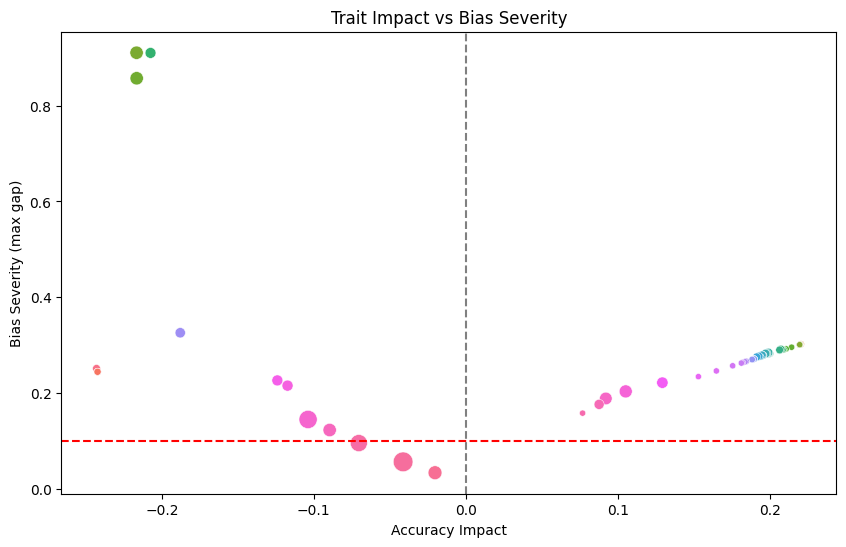

TRAIT OUTCOME DRIVER
🔎 Outcome Driver Analysis
We examine each trait/label to see how they relate to four possible outcomes:
  - TP: invasive correctly classified
  - TN: non-invasive correctly classified
  - FP: non-invasive misclassified as invasive (false alarm)
  - FN: invasive misclassified as non-invasive (missed invasive)
First, we compute simple fractions. Then, we fit logistic regression and random forest models.

📊 Top drivers of prediction outcomes (fraction-based, normalized):


,feature,n_with,n_without,TP_share,TN_share,FP_share,FN_share,max_driver
26,has_leaves opposite,60780,71348,0.512721,0.416180,0.477888,0.515791,0.515791
56,has_sessile,51059,81069,0.512721,0.281330,0.443824,0.515791,0.515791
1,has_alternate distally,24221,107907,0.445851,0.000000,0.010162,0.432662,0.445851
54,has_rounded at the base,24225,107903,0.445851,0.000057,0.010162,0.432662,0.445851
2,has_base attenuate,22821,109307,0.000000,0.281473,0.433233,0.000000,0.433233
5,has_becoming alternate distally,20929,111199,0.000000,0.255308,0.425791,0.000000,0.425791
11,has_erect,44067,88061,0.411501,0.267764,0.369543,0.415918,0.415918
14,has_floral tube cylindrical,24221,107907,0.248963,0.127512,0.223129,0.251112,0.251112



📝 Interpretation (fractions):
- Traits most linked to FALSE POSITIVES: has_leaves opposite, has_sessile, has_base attenuate (shares ~ 0.48, 0.44, 0.43).
- Traits most linked to FALSE NEGATIVES: has_leaves opposite, has_sessile, has_alternate distally (shares ~ 0.52, 0.52, 0.43).
- Traits most linked to correct invasive detection (TP): has_leaves opposite, has_sessile, has_alternate distally.
- Traits most linked to correct non-invasive detection (TN): has_leaves opposite, has_base attenuate, has_sessile.

📈 Logistic Regression Meta-Model (multinomial)
Top normalized coefficients (strongest drivers per outcome):


,FN,FP,TN,TP
4 minute petals,0.005418,0.004723,0.011664,0.005426
a discernible gap between the stem and the base of the blade,0.041280,0.035928,0.088153,0.040473
alternate distally,0.716538,0.115049,0.981441,0.712095
base attenuate,1.000000,0.657999,1.000000,1.000000
base narrowly attenuate,0.013736,0.003752,0.017640,0.013639
base obtuse to truncate,0.232885,0.491643,0.015725,0.240841
base rounded,0.053753,0.062725,0.128220,0.054547
becoming alternate distally,0.779596,1.000000,0.413024,0.779717



📝 Interpretation (logistic regression):
- Strongest predictors of TP: base attenuate, getting narrower at the base, becoming alternate distally
- Strongest predictors of TN: base attenuate, alternate distally, getting narrower at the base
- Strongest predictors of FP: becoming alternate distally, getting narrower at the base, base attenuate
- Strongest predictors of FN: base attenuate, getting narrower at the base, becoming alternate distally

🌲 Random Forest Meta-Model
Top feature importances:


,feature,importance
2,alternate distally,0.162932
64,rounded at the base,0.154439
84,with flowers in whorled clusters,0.066783
3,base attenuate,0.066629
7,becoming alternate distally,0.055464
66,sessile,0.053759
9,calyx with alternate long and small teeth,0.048859
23,getting narrower at the base,0.047704



📝 Interpretation (random forest):
- Traits with strongest overall predictive importance: alternate distally, rounded at the base, with flowers in whorled clusters, base attenuate, becoming alternate distally.

Outcome-specific feature importances (normalized per outcome):


,TP,TN,FP,FN
4 minute petals,0.000040,0.000059,0.000030,0.000033
a discernible gap between the stem and the base of the blade,0.003621,0.005030,0.004146,0.004531
alternate distally,1.000000,1.000000,0.239894,1.000000
base attenuate,0.505533,0.378220,0.730070,0.490735
base narrowly attenuate,0.000104,0.000094,0.000450,0.000059
base obtuse to truncate,0.053947,0.076577,0.010558,0.050199
base rounded,0.003062,0.005675,0.003837,0.003041
becoming alternate distally,0.372754,0.267073,1.000000,0.387122



📝 Interpretation (random forest outcome-specific):
- Strongest predictors of TP: alternate distally, rounded at the base, base attenuate
- Strongest predictors of TN: alternate distally, rounded at the base, with flowers in whorled clusters
- Strongest predictors of FP: becoming alternate distally, base attenuate, stamens 6
- Strongest predictors of FN: alternate distally, rounded at the base, base attenuate


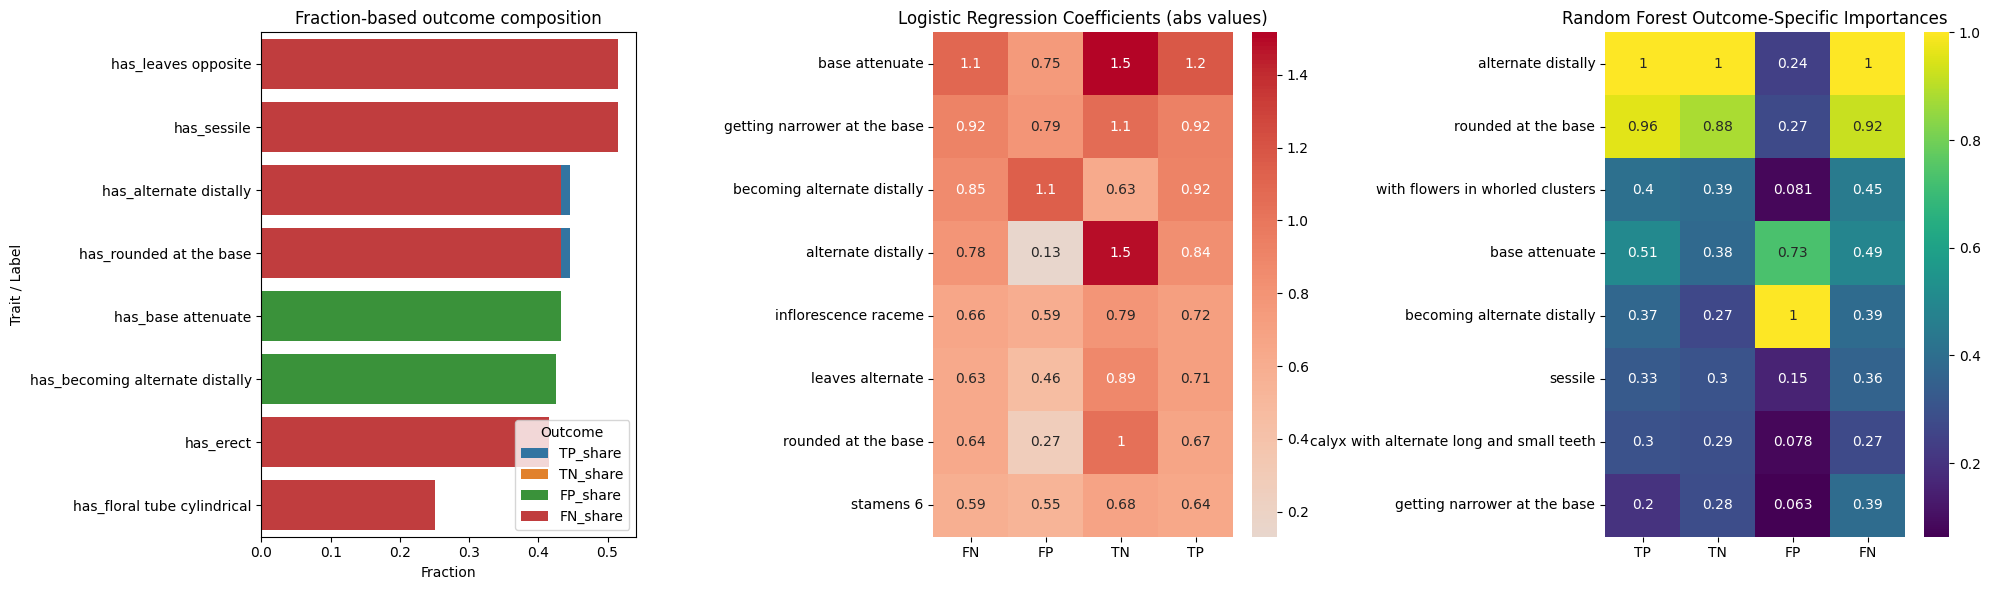

POLARIZING TRAIT ANALYSIS (TP/TN/FP/FN Shifts)
POLARIZING TRAIT ANALYSIS
Analyzing traits with at least 10 samples to detect TP/TN/FP/FN shifts.

Most polarizing trait: 'getting narrower at the base' with asymmetry score 0.352
  - TP change: +0.000, TN change: +0.000
  - FP change: -0.055, FN change: +0.298
Interpretation: This trait strongly shifts predictions: its effect aligns with overall accuracy (mostly helps or hurts consistently).
                                        trait  tp_change  tn_change  \
21               getting narrower at the base        0.0        0.0   
66                              stamens 10-14        0.0        0.0   
48                      petals rose to purple        0.0        0.0   
24          inflorescence spikelike to raceme        0.0        0.0   
1                          alternate distally        0.0        0.0   
57                        rounded at the base        0.0        0.0   
75           with flowers in whorled clusters        0.0    

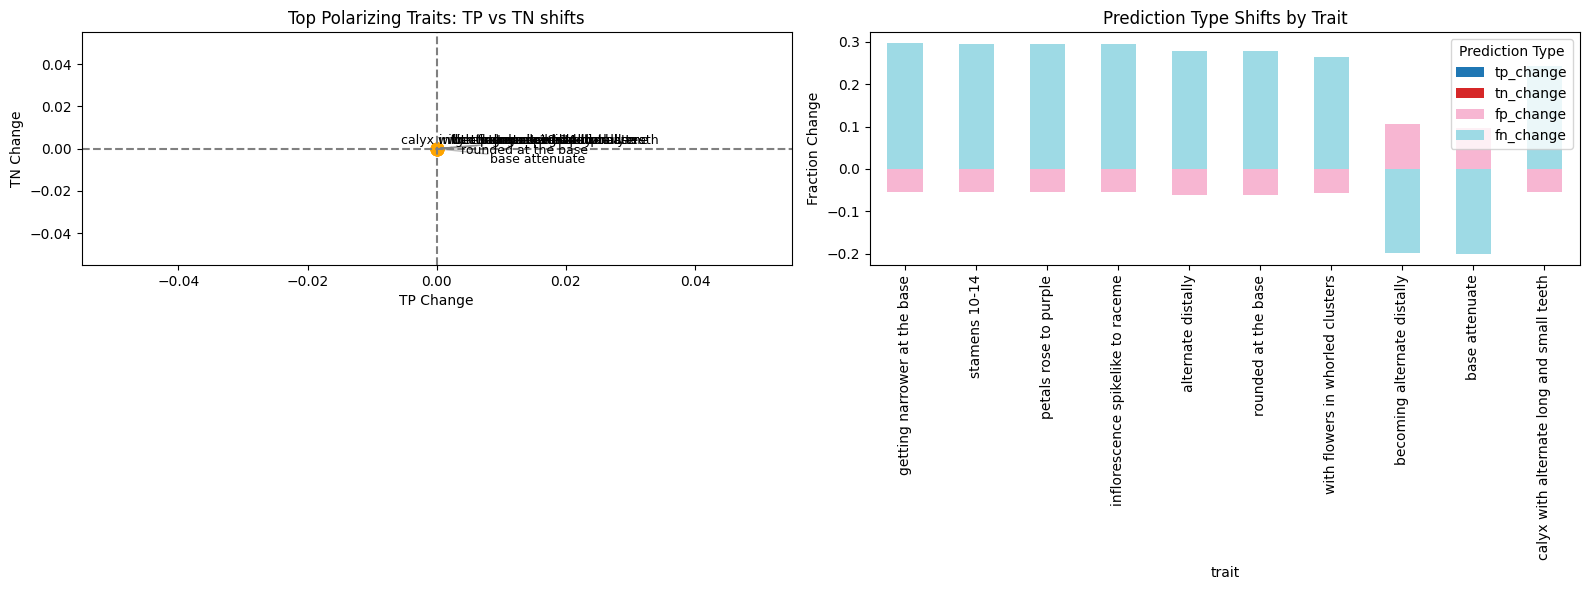

ANNOTATION LABEL IMPACT
ANNOTATION LABEL IMPACT ANALYSIS
This analyzes how annotation quality affects model performance

1. 'HAND' LABEL IMPACT:
   (shows counts including missing values and performance metrics per value)

   Value counts (including Missing):
     Missing      n=120,493 (91.2%)
     1.0          n=11,635 (8.8%)

   Results by 'HAND' Label Value:
     1.0         : Acc=0.778, Prec=0.825, Rec=0.598 (n=11,635 samples)
     Missing     : Acc=0.781, Prec=0.824, Rec=0.598 (n=120,493 samples)

   Accuracy difference (1.0 vs Missing): -0.003

   Statistical test: Chi-square => NOT significant (p=0.5962)

2. 'BACKGROUND/UNDEFINED' LABEL IMPACT:
   (shows counts including missing values and performance metrics per value)

   Value counts (including Missing):
     Missing      n=93,769 (71.0%)
     1.0          n=38,359 (29.0%)

   Results by 'BACKGROUND/UNDEFINED' Label Value:
     1.0         : Acc=0.782, Prec=0.823, Rec=0.600 (n=38,359 samples)
     Missing     : Acc=0.780, Pr

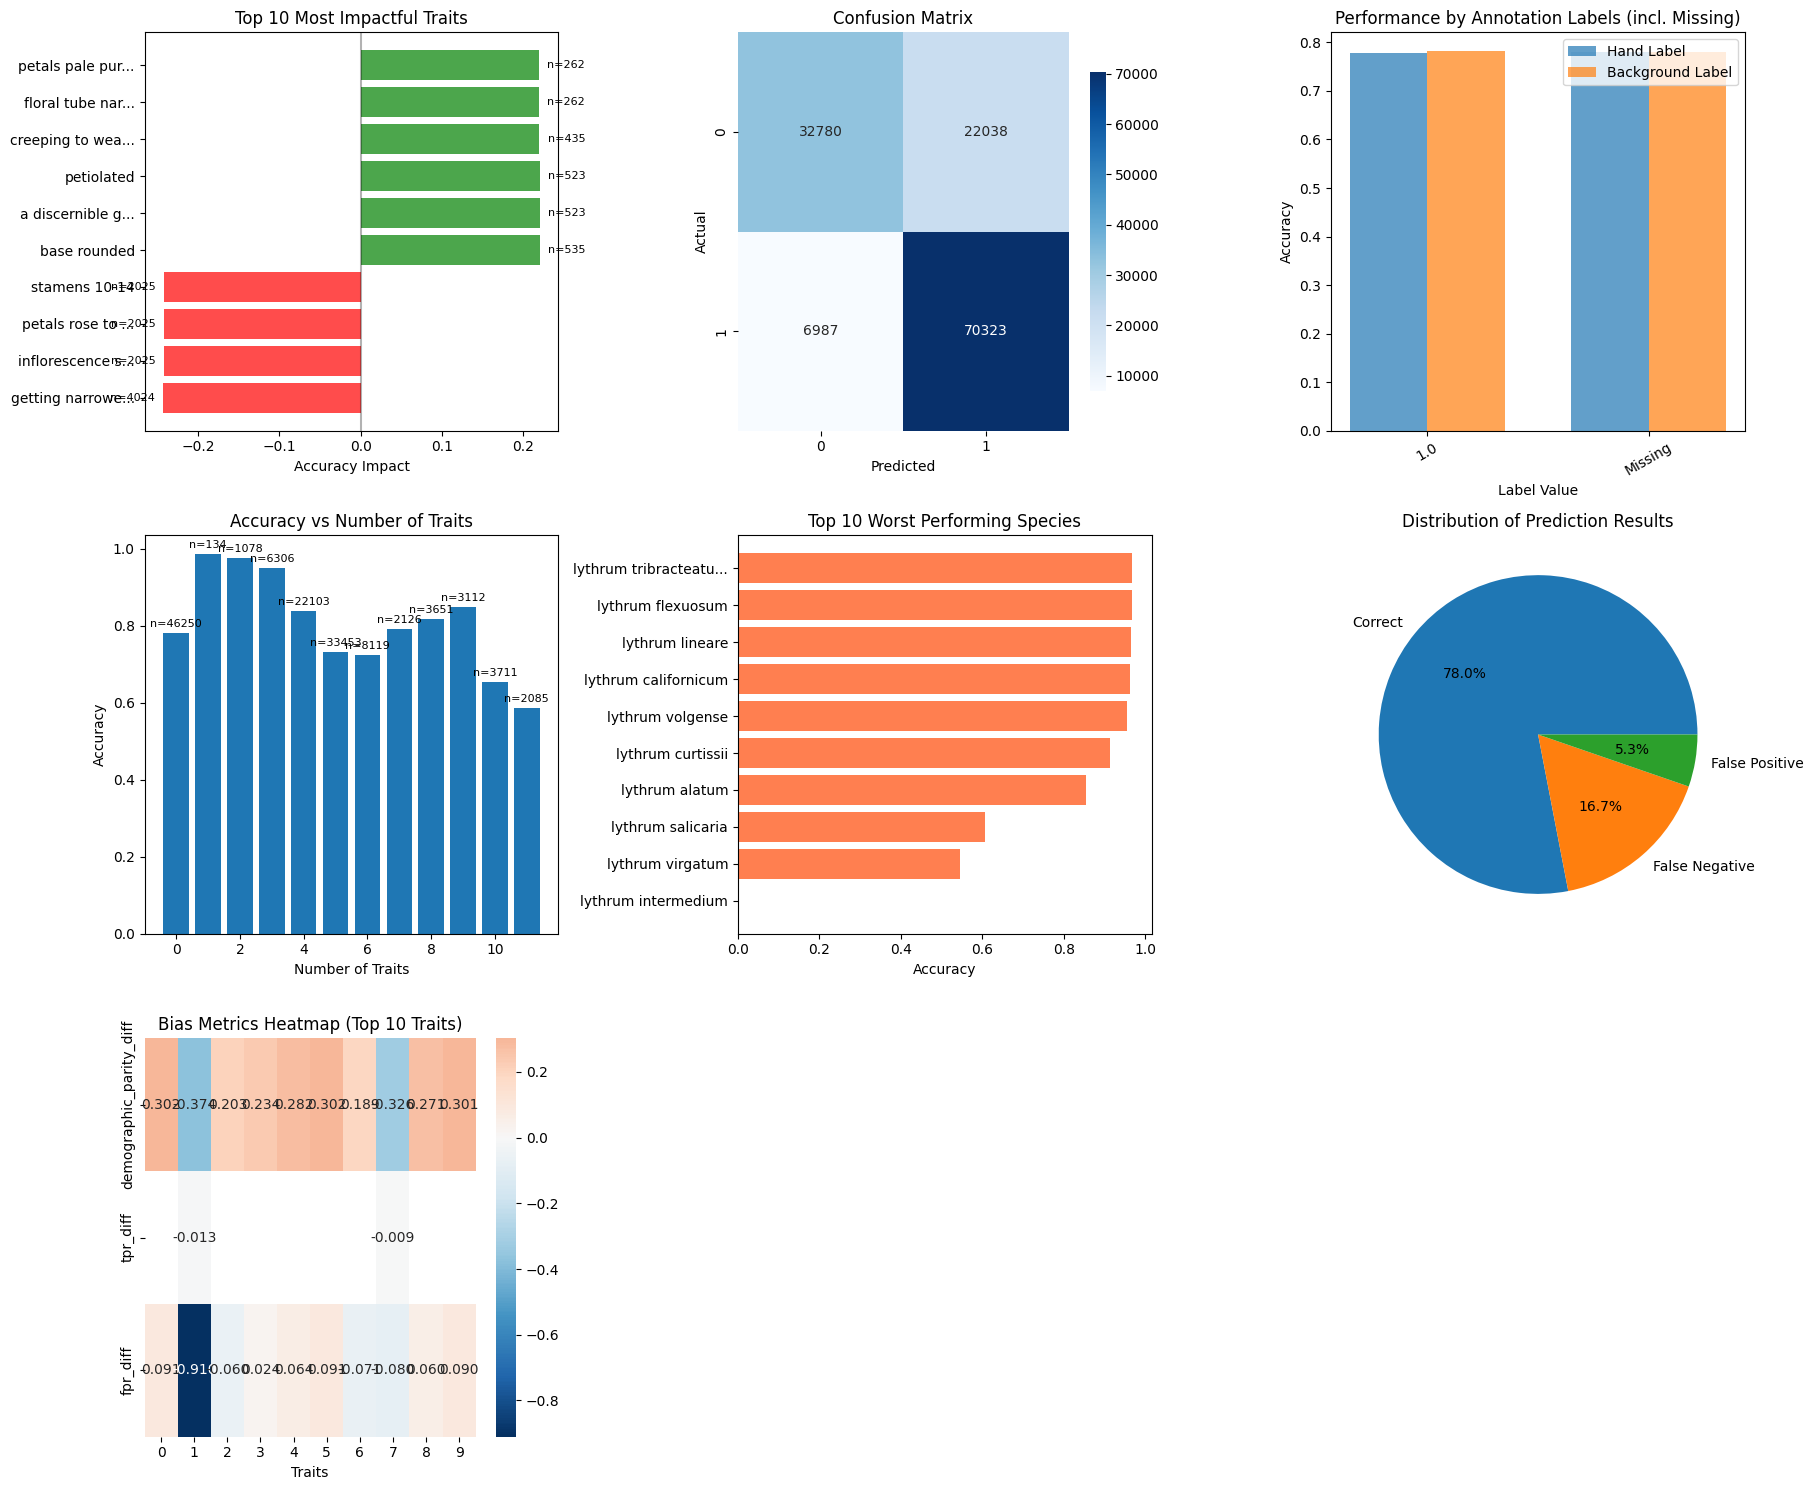

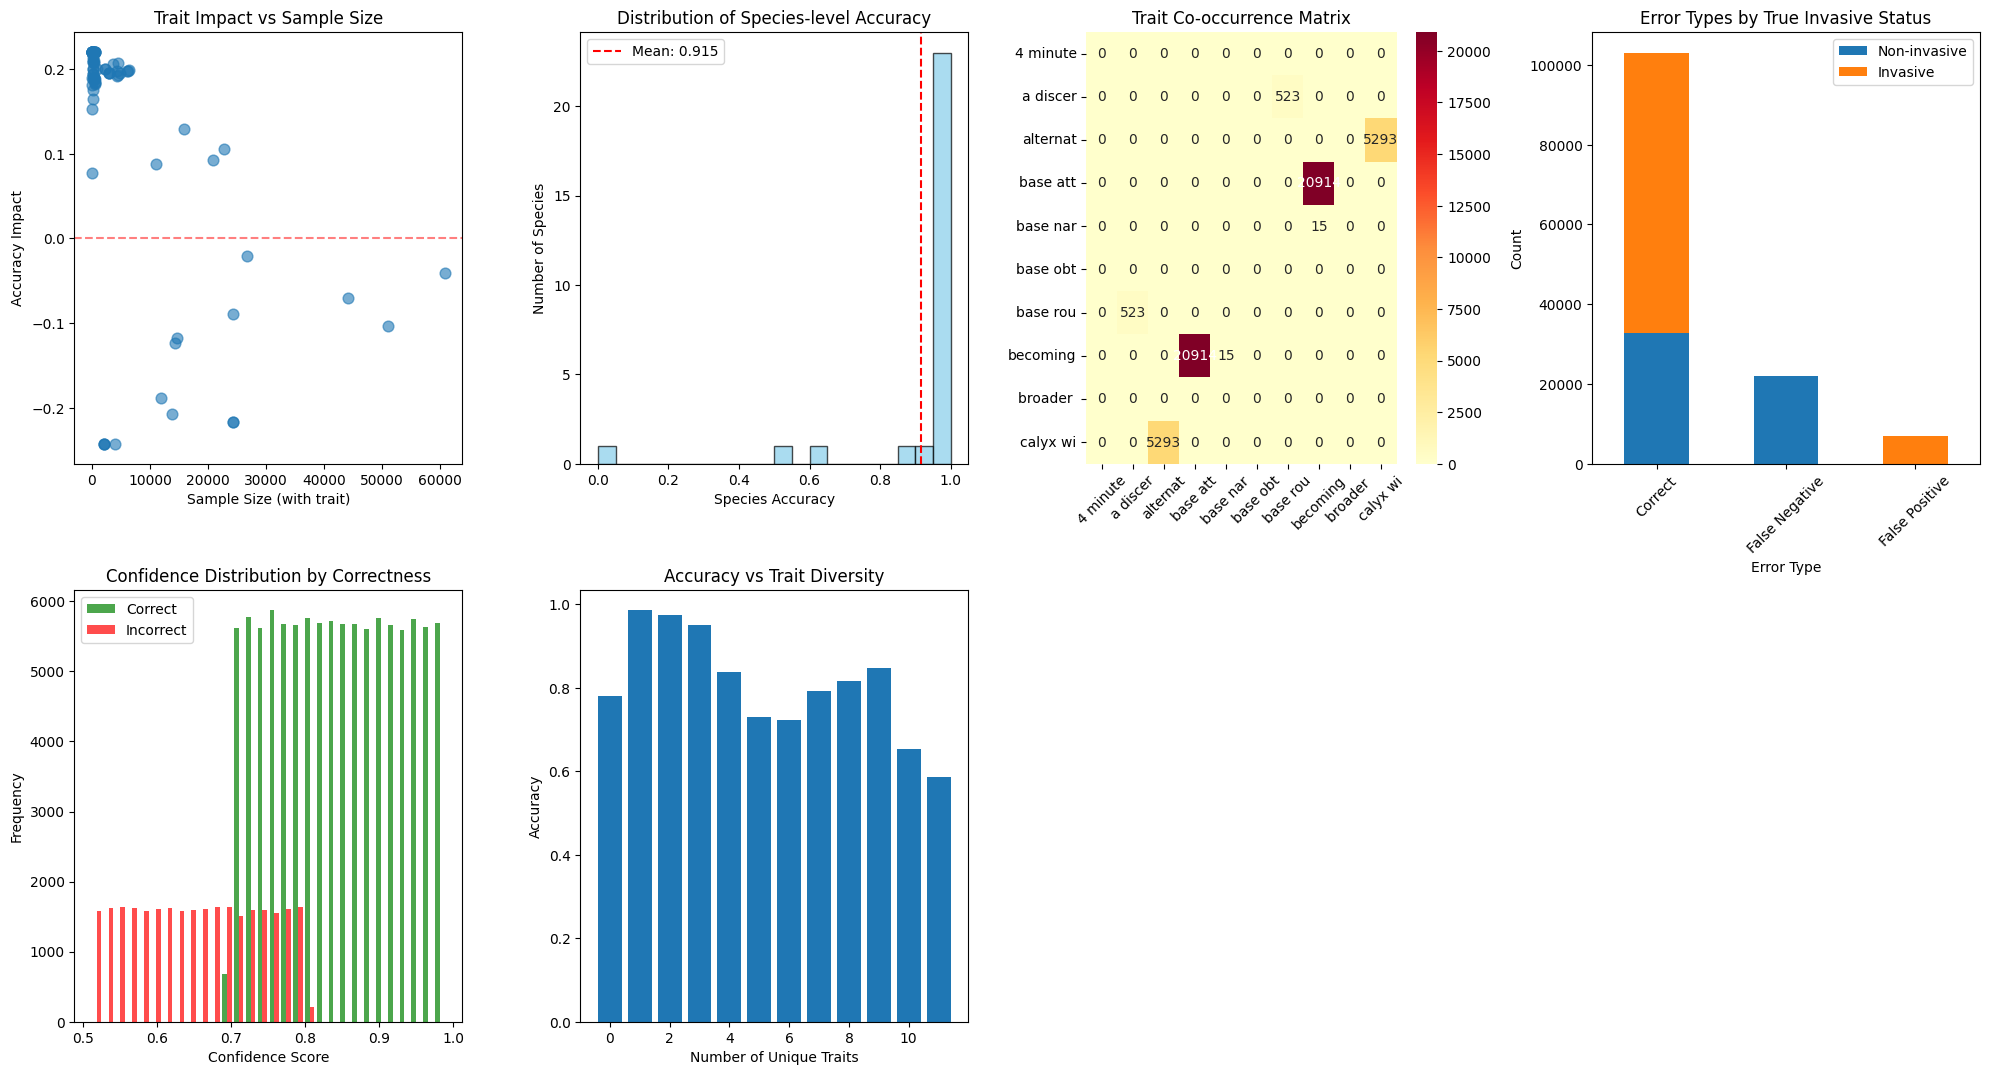

ANALYSIS COMPLETE


In [46]:
analyzer = ImprovedPlantModelAnalyzer(merged_df)

results = analyzer.comprehensive_summary_report()

for key, value in results.items():
    if hasattr(value, 'to_csv'):
        value.to_csv(f'regions_results/{key}.csv', index=False)